# 🧬 Behavioral Analytics: The Modern Student Triad
### Exploring AI Dependency, Career Anxiety, and Student Burnout

#### 🧠 Project Motivation
Most publicly available education datasets focus strictly on traditional performance metrics like grades, test scores, or attendance records. While useful, they completely miss the massive psychological shifts occurring in the generative AI era. 

This notebook explores the intersection of three highly correlated contemporary phenomena: **Generative AI Dependency**, **Acute Career Anxiety**, and **Chronic Student Burnout**. Rather than existing as isolated issues, these factors form a compounding psychological feedback loop that alters how students learn, cope, and view their professional futures.

#### 🛠️ Dataset Design Philosophy
Unlike simplistic synthetic datasets with perfectly linear relationships, this dataset was intentionally engineered to include real-world dataset characteristics:
* **Overlapping Behaviors:** Students exhibiting high AI usage alongside high manual study efforts.
* **Contradictory Personas:** High-performing students tracking high burnout levels.
* **Controlled Missingness:** Simulating real-world survey drops or unrecorded tracking metrics.
* **Moderate Correlations:** Introducing realistic noise and variance to prevent trivial decision boundaries.

#### Automated Data Ingestion
To ensure maximum reproducibility and maintain clean versioning, we pull the official dataset directly from Kaggle utilizing the `kagglehub` library. 

This automated process fetches the raw behavioral data tracking AI usage metrics, burnout indicators, and career anxiety scales directly into our environment.

* **Dataset Credit:** Sridip Basu via Kaggle (*AI Dependency, Career Anxiety, and Student Burnout Dataset*).

### 📥 Loading the Dataset and Libraries

Before we start, we need to install the necessary Python libraries and **load the dataset**.


In [1]:
# Install the required libraries
%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn -q

%pip install ucimlrepo -q
# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# IMPORT REQUIRED MODULES - Data manipulation and visualization

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-Processing and Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

c:\Users\LarTI\OneDrive\Desktop\Projects\AI_Dependency\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of the specific student behavioral dataset
path = kagglehub.dataset_download("sridipbasu/ai-depndency-career-anxiety-and-student-burnout")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\sridipbasu\ai-depndency-career-anxiety-and-student-burnout\versions\1


In [4]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

csv_filename = [file for file in all_files if file.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_filename)

📂 Files discovered in directory: ['ai_dependency_career_anxiety_students.csv', 'dataset_metadata.json', 'feature_dictionary.csv']


In [5]:
# Load the data directly into a primary Pandas DataFrame matrix
df = pd.read_csv(full_csv_path)
print("✅ Data successfully loaded into DataFrame named 'df'!")

✅ Data successfully loaded into DataFrame named 'df'!


In [6]:
# Display the first 5 records to see our column properties and labels
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [7]:
# It returns the dimensions of the DataFrame as a tuple
df.shape

(15000, 30)

In [8]:
df.sample(15) # Random 15 rows

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
7804,STU_07805,21,Male,B.Tech/B.E.,CS/IT,1,Tier 3,Rural,6.1,Claude,...,2.7,13.1,2,3.7,6.6,7,7,1,1.0,5.55
9563,STU_09564,19,Male,B.Sc/B.A/B.Com,Engineering (Non-CS),2,Tier 1,Urban,3.0,ChatGPT,...,6.5,16.1,4,2.3,7.1,6,7,3,0.0,9.45
6031,STU_06032,24,Female,B.Tech/B.E.,Arts/Sciences,2,Tier 1,Urban,0.0,NaN,...,3.0,8.1,5,1.9,8.2,5,6,5,0.0,7.88
10411,STU_10412,24,Male,B.Tech/B.E.,CS/IT,2,Tier 3,Urban,4.3,GitHub Copilot,...,1.0,9.5,4,2.8,6.0,6,7,3,1.0,6.72
5722,STU_05723,19,Female,B.Tech/B.E.,Arts/Sciences,3,Tier 2,Urban,4.2,Claude,...,2.1,5.6,2,1.5,5.1,7,7,1,1.0,6.52
6578,STU_06579,24,Female,MBA,Engineering (Non-CS),2,Tier 3,Urban,0.4,Claude,...,2.3,6.8,1,3.9,7.6,2,3,6,0.0,6.07
13332,STU_13333,21,Female,B.Tech/B.E.,Arts/Sciences,1,Tier 2,Rural,0.0,NaN,...,3.5,1.0,1,1.4,6.6,7,8,5,0.0,5.29
3368,STU_03369,26,Female,MBA,CS/IT,2,Tier 3,Urban,1.9,Gemini,...,3.6,11.3,4,5.8,7.1,6,3,6,0.0,6.79
10048,STU_10049,20,Female,B.Tech/B.E.,CS/IT,3,Tier 3,Urban,3.8,Perplexity,...,1.7,18.1,3,2.2,7.5,6,7,4,0.0,8.60
4392,STU_04393,22,Male,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Rural,3.0,ChatGPT,...,2.7,9.5,1,3.4,6.0,8,7,6,1.0,5.19


In [9]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
14995,STU_14996,21,Female,B.Sc/B.A/B.Com,CS/IT,1,Tier 3,Urban,2.8,ChatGPT,...,0.0,6.2,2,0.2,9.6,4,6,2,0.0,7.02
14996,STU_14997,22,Male,B.Tech/B.E.,Commerce/Management,4,Tier 1,Urban,3.6,ChatGPT,...,6.1,11.7,3,2.9,5.8,5,3,9,1.0,7.31
14997,STU_14998,22,Male,B.Tech/B.E.,CS/IT,2,Tier 1,Rural,1.7,Gemini,...,6.3,17.2,5,0.6,7.4,3,1,9,0.0,8.65
14998,STU_14999,22,Female,MBA,CS/IT,2,Tier 2,Urban,0.0,NaN,...,0.8,0.0,1,2.0,9.1,5,6,2,0.0,4.97
14999,STU_15000,23,Male,M.Tech/M.Sc,Engineering (Non-CS),2,Tier 3,Rural,2.1,ChatGPT,...,2.9,1.0,3,3.9,7.4,7,7,4,0.0,5.28


## 🧹 Data Preprocessing & Hygiene
Now that the data is loaded, we begin our cleaning pipeline. 
Our tasks in this phase are:
1. **Find the missing data:** Using the command **df.isna().sum()** 
2. **Drop Identifiers:** Remove `student_id` since it has no predictive or statistical power.
3. **Handle Missing Data:** Clean the columns containing missing values ($NaN$) using imputation strategies:
   * **Categorical Imputation:** Fill high-missingness text columns like `primary_ai_tools_used` with a default placeholder (`'None'`).
   * **Numerical Imputation:** Fill missing numerical features with their **Median** values to keep our distributions stable and unaffected by outliers.

In [10]:
df.isna().sum()  # You can also use df.isnull().sum() — both do the same thing

student_id                            0
age                                   0
gender                                0
degree_type                           0
stream                                0
year_of_study                         0
college_tier                          0
urban_or_rural                        0
daily_ai_tool_usage_hrs               0
primary_ai_tools_used              3215
uses_ai_for_assignments               0
ai_replaces_own_thinking_score        0
ai_dependency_score                   0
placement_anxiety_score               0
fear_of_job_loss_to_ai                0
career_clarity_score                  0
internship_experience                 0
weekly_job_application_count          0
resume_confidence_score               0
interview_anxiety_score               0
daily_study_hours                     0
self_learning_hours_per_week        233
skill_development_courses_taken       0
social_media_hrs_per_day            210
sleep_hours                         203


In [11]:
# We use errors='ignore' so the cell can be re-run safely without crashing
df.drop(columns=['student_id'], inplace=True, errors='ignore')
print("🗑️ Dropped 'student_id' column successfully.")

🗑️ Dropped 'student_id' column successfully.


In [12]:
# For 'primary_ai_tools_used', the massive gaps mean the student likely doesn't use tools.
# We fill these with 'None' to preserve the records.
df['primary_ai_tools_used'] = df['primary_ai_tools_used'].fillna('None')

In [13]:
# For 'seeks_career_counseling', we fill missing values with the most common answer (Mode)
counseling_mode = df['seeks_career_counseling'].mode()[0]
df['seeks_career_counseling'] = df['seeks_career_counseling'].fillna(counseling_mode)

In [14]:
# We select the numerical columns that showed missing values in our initial check
missing_num_cols = ['self_learning_hours_per_week', 'social_media_hrs_per_day', 'sleep_hours']

# Loop through each column and replace NaN values with that column's median
for col in missing_num_cols:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

print("🎯 Missing values handled using clinical imputation strategies.")

🎯 Missing values handled using clinical imputation strategies.


In [15]:
# Check the remaining total number of missing entries across the entire dataset
remaining_nans = df.isna().sum().sum()
print(f"🛑 Remaining Missing Values in DataFrame: {remaining_nans}")
print(f"📊 Cleaned Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")

🛑 Remaining Missing Values in DataFrame: 0
📊 Cleaned Dataset Dimensions: 15000 rows, 29 columns.



In [16]:
# Display a preview of the clean dataset
df.head()

,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,uses_ai_for_assignments,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,Never,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,Rarely,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,Sometimes,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,Frequently,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,Sometimes,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              15000 non-null  int64  
 1   gender                           15000 non-null  str    
 2   degree_type                      15000 non-null  str    
 3   stream                           15000 non-null  str    
 4   year_of_study                    15000 non-null  int64  
 5   college_tier                     15000 non-null  str    
 6   urban_or_rural                   15000 non-null  str    
 7   daily_ai_tool_usage_hrs          15000 non-null  float64
 8   primary_ai_tools_used            15000 non-null  str    
 9   uses_ai_for_assignments          15000 non-null  str    
 10  ai_replaces_own_thinking_score   15000 non-null  int64  
 11  ai_dependency_score              15000 non-null  int64  
 12  placement_anxiety_score      

## 🗂️ Data Type Conversion & Memory Optimization
With a clean dataset containing 0 missing values, we audit our structural data types to ensure proper parsing:
1. **Categorical Categorization:** Convert text object columns (`str`) into pandas categorical variables (`category`) to optimize memory and prep for one-hot encoding.
2. **Binary Alignment:** Fix float formats on logical indicators like `seeks_career_counseling` to cast them into clean integer flags.

In [18]:
# --- 1. IDENTIFY CATEGORICAL TEXT COLUMNS ---
# Explicitly listing columns that contain categorical group text labels
text_categorical_cols = [
    'gender', 'degree_type', 'stream', 'college_tier', 
    'urban_or_rural', 'primary_ai_tools_used', 'uses_ai_for_assignments'
]

# Convert these columns into pandas category data types
for col in text_categorical_cols:
    df[col] = df[col].astype('category')

print("✨ Successfully converted text columns to categorical groups!")

# --- 2. RE-ALIGN INT AND FLOAT INDICATORS ---
# 'seeks_career_counseling' is a binary flag stored as a float. Let's convert it to integer.
# We cast it to int64 for numerical parity with our other score metrics
df['seeks_career_counseling'] = df['seeks_career_counseling'].astype('int64')

print("🎯 Successfully converted flag indicators to clean integer types.")

# --- 3. FINAL TYPE VERIFICATION AUDIT ---
# Print the updated dataframe structure summary
print("\n--- 📋 Updated DataFrame Type Summary ---")
df.info()

✨ Successfully converted text columns to categorical groups!
🎯 Successfully converted flag indicators to clean integer types.

--- 📋 Updated DataFrame Type Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              15000 non-null  int64   
 1   gender                           15000 non-null  category
 2   degree_type                      15000 non-null  category
 3   stream                           15000 non-null  category
 4   year_of_study                    15000 non-null  int64   
 5   college_tier                     15000 non-null  category
 6   urban_or_rural                   15000 non-null  category
 7   daily_ai_tool_usage_hrs          15000 non-null  float64 
 8   primary_ai_tools_used            15000 non-null  category
 9   uses_ai_for_assignments          150

## 📊 Exploratory Data Analysis (EDA)
With a fully sanitized and optimized dataset, we now visually investigate the behavioral dynamics of the modern student triad. Our exploration focuses on three core questions:
1. **Describe the data**
2. **The Core Triangle Correlation:** How tightly woven are AI dependency scores, burnout ratings, and placement anxiety?
3. **The Shift in Vitals:** Does excessive daily AI tool usage systematically degrade a student's sleep patterns and baseline stress?
4. **The Disruption Across Streams:** Which academic fields face the highest levels of career dread and fear of job loss to automation?

In [19]:
df.describe(include='all')  # Generates descriptive statistics for all numeric columns in your DataFrame.

,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,uses_ai_for_assignments,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000,15000,15000,15000.000000,15000,15000,15000.000000,15000,15000,...,15000.000000,15000.000000,15000.0000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,4,4,NaN,3,2,NaN,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,B.Tech/B.E.,CS/IT,NaN,Tier 3,Urban,NaN,ChatGPT,Never,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7840,6700,6091,NaN,7475,10282,NaN,5469,4603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,21.384533,NaN,NaN,NaN,2.100067,NaN,NaN,2.013893,NaN,NaN,...,2.730660,6.292113,2.0326,3.006347,6.993453,4.771133,5.472600,4.319733,0.281600,5.998019
std,2.005626,NaN,NaN,NaN,0.987650,NaN,NaN,1.735977,NaN,NaN,...,1.801026,5.511472,1.8095,1.637448,0.997986,1.778210,2.068317,2.151266,0.449794,1.593982
min,18.000000,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,NaN,NaN,NaN,1.000000,NaN,NaN,0.400000,NaN,NaN,...,1.300000,1.100000,1.0000,1.900000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,NaN,NaN,NaN,2.000000,NaN,NaN,1.800000,NaN,NaN,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,NaN,NaN,NaN,3.000000,NaN,NaN,3.200000,NaN,NaN,...,4.000000,10.000000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000


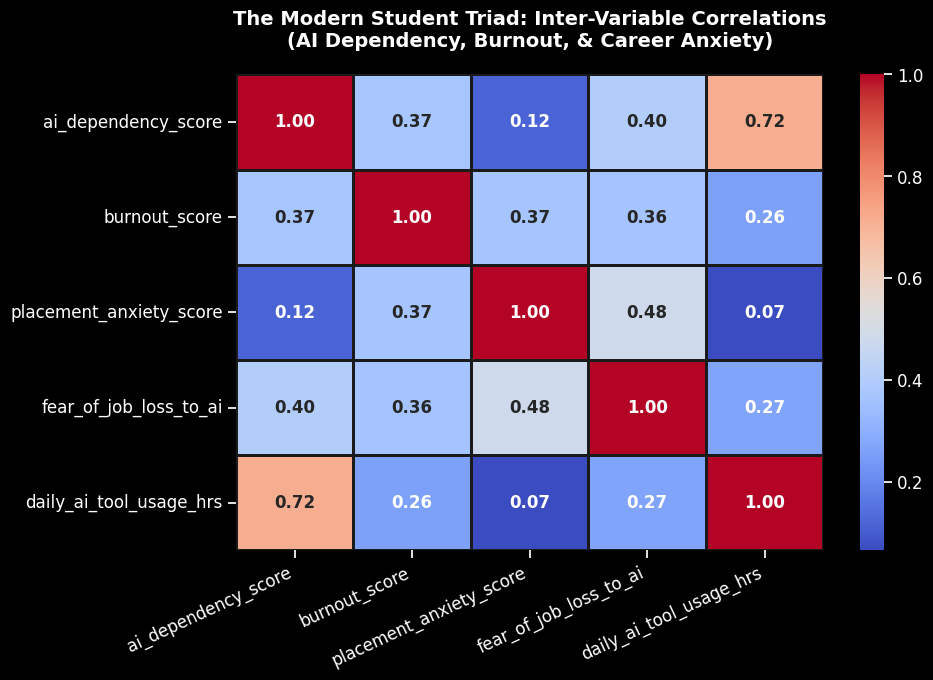

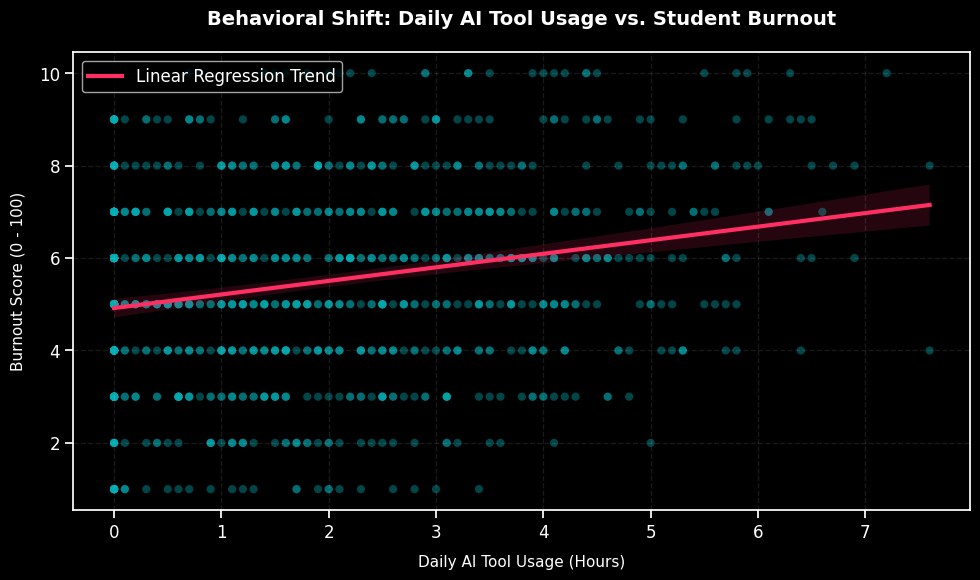

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SET THE SLEEK DARK MODE AESTHETIC ---
# Setting notebook context for clear, large text readability
sns.set_context("notebook", font_scale=1.1)
# Applying dark mode background styling to match portfolio guidelines 🌑
plt.style.use('dark_background')

# --- 2. GRAPH 1: THE RELEVANT TRIAD CORRELATION HEATMAP ---
# Isolating only the most relevant numerical features to prevent a cluttered matrix
relevant_cols = [
    'ai_dependency_score', 
    'burnout_score', 
    'placement_anxiety_score', 
    'fear_of_job_loss_to_ai', 
    'daily_ai_tool_usage_hrs'
]

# Compute the correlation matrix from our isolated features
triad_corr = df[relevant_cols].corr()

# Initialize an individual figure for maximum stability across notebook backends
plt.figure(figsize=(10, 7))

# Plot the heatmap using a sharp coolwarm divergent color scale
sns.heatmap(
    triad_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=1, 
    linecolor='#1a1a1a',
    annot_kws={'size': 12, 'weight': 'bold'}
)

plt.title('The Modern Student Triad: Inter-Variable Correlations\n(AI Dependency, Burnout, & Career Anxiety)', fontsize=14, pad=20, weight='bold')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save image file for portfolio deployment documentation
plt.savefig('student_triad_correlation.png', dpi=300)
plt.show()


# --- 3. GRAPH 2: DAILY AI USAGE HOURS VS. BURNOUT TREND ---
plt.figure(figsize=(10, 6))

# Sample 1,000 students to prevent canvas over-saturation while maintaining true distribution
df_sample = df.sample(n=min(1000, len(df)), random_state=42)

# Fit a linear regression model trendline over our scatter plot mapping
sns.regplot(
    data=df_sample, 
    x='daily_ai_tool_usage_hrs', 
    y='burnout_score',
    scatter_kws={'alpha': 0.4, 'color': '#00ADB5', 'edgecolor': 'none', 's': 35},
    line_kws={'color': '#FF2E63', 'linewidth': 3, 'label': 'Linear Regression Trend'}
)

plt.title('Behavioral Shift: Daily AI Tool Usage vs. Student Burnout', fontsize=14, pad=20, weight='bold')
plt.xlabel('Daily AI Tool Usage (Hours)', fontsize=11, labelpad=10)
plt.ylabel('Burnout Score (0 - 100)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.1)
plt.legend(loc='upper left')
plt.tight_layout()

# Save image file for portfolio deployment documentation
plt.savefig('ai_usage_vs_burnout.png', dpi=300)
plt.show()

# The code was made by ChatGPT with my touches and guidance.

## 🎯 Defining Target (y) and Features (X)
To train a predictive model, we must separate our dataset into two distinct mathematical matrices:
1. **Target Variable ($y$):** We engineer a binary classification target based on the `ai_dependency_score`. Students scoring above the median are flagged as `1` (High Dependency Risk), while others are classified as `0`.
2. **Feature Matrix ($X$):** The collection of columns (such as burnout scores, career clarity, sleep hours, and stream) that the model will evaluate to find predictive patterns. We drop columns directly used to calculate the target to prevent data leakage.

In [21]:
# --- ENGINEER THE BINARY TARGET COLUMN (y) ---
# Calculate the median threshold for the AI dependency score
dependency_threshold = df['ai_dependency_score'].median()
print(f"📊 Median AI Dependency Threshold Score: {dependency_threshold}")

# Create a binary target: 1 if above median (High Risk), 0 if below/equal
df['High_AI_Dependency_Risk'] = (df['ai_dependency_score'] > dependency_threshold).astype(int)

# Isolate y
y = df['High_AI_Dependency_Risk']

# --- ISOLATE THE FEATURE MATRIX (X) ---
# We select our predictive columns. 
# Crucial: We must drop any columns that directly reveal or calculate the target 
# to prevent "Data Leakage" (which would give our model fake 100% accuracy).
columns_to_drop = [
    'High_AI_Dependency_Risk',    # Drop the target itself
    'ai_dependency_score',         # Drop the direct numerical score leak
    'daily_ai_tool_usage_hrs',     # Drop usage hours as it directly builds dependency
    'ai_replaces_own_thinking_score' # Drop thinking score as it acts as a direct leak
]

X = df.drop(columns=columns_to_drop)

# --- DUMMY ENCODING FOR CATEGORICAL FEATURES ---
# Machine learning models cannot read raw text categories like 'Computer Science' or 'Gender'.
# We use One-Hot Encoding to convert categories into binary 1s and 0s automatically.
X = pd.get_dummies(X, drop_first=True)

print("✅ Features (X) and Target (y) successfully separated.")

# --- 4. SHAPE VERIFICATION ---
# Verify that the row counts match perfectly, but X has multiple feature columns
print(f"📐 Dimensions of Feature Matrix (X): {X.shape[0]} rows, {X.shape[1]} columns.")
print(f"📐 Dimensions of Target Vector (y): {y.shape[0]} elements.")

# Check the baseline balance of our target variable
print("\n🎯 Target Class Distribution (0 = Balanced, 1 = High Dependency):")
print(y.value_counts(normalize=True))

📊 Median AI Dependency Threshold Score: 4.0
✅ Features (X) and Target (y) successfully separated.
📐 Dimensions of Feature Matrix (X): 15000 rows, 39 columns.
📐 Dimensions of Target Vector (y): 15000 elements.

🎯 Target Class Distribution (0 = Balanced, 1 = High Dependency):
High_AI_Dependency_Risk
0    0.5228
1    0.4772
Name: proportion, dtype: float64


## 🧪 Train-Test Partitioning & Feature Scaling
To evaluate our model's real-world predictive validity, we must partition our processed matrices:
1. **Train-Test Split:** We allocate 80% of our data to train the model, holding back 20% as a completely unseen test bank to evaluate performance.
2. **Feature Standardization:** We apply `StandardScaler` to normalize our numerical metrics. This centers our features around a mean of 0 and a standard deviation of 1, preventing high-magnitude scores from dominating model weights.

In [22]:
# --- EXECUTE THE TRAIN-TEST SPLIT ---
# test_size=0.20 reserves 20% of the data for testing (3,000 out of 15,000 students)
# random_state=42 locks the shuffle seed so your split is identical every time you run it
# stratify=y ensures that our target class balance (High vs Low risk) is perfectly mirrored in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

print("✂️ Dataset successfully split into independent subsets:")
print(f"   • Training Features (X_train): {X_train.shape}")
print(f"   • Testing Features (X_test):   {X_test.shape}")

# --- PPLY FEATURE STANDARDIZATION ---
# Initialize the standardizer object
scaler = StandardScaler()

# CRUCIAL DATA SCIENCE STEP:
# We ONLY fit the scaler on the training data so it learns the means and variations.
# Then we transform both training and testing datasets using those learned weights.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("⚖️ Feature scales standardized smoothly.")

# --- VERIFY TRANSLATION ---
# Let's print out what the first student's features look like post-scaling
print("\n📝 Sample array of standard scaled features (First Student):")
print(X_train_scaled[0][:5]) # Displaying just the first 5 scaled features

✂️ Dataset successfully split into independent subsets:
   • Training Features (X_train): (12000, 39)
   • Testing Features (X_test):   (3000, 39)
⚖️ Feature scales standardized smoothly.

📝 Sample array of standard scaled features (First Student):
[-0.19104568 -0.10787651  1.20972276  0.38544331 -1.82558352]


## 🤖 Model Training, Evaluation & Behavioral Insights
With our feature matrices perfectly scaled, we enter the final execution phase:
1. **Model Initialization:** We train a **Random Forest Classifier** to decode the patterns connecting student burnout and career anxiety to high AI dependency.
2. **Performance Evaluation:** We evaluate our model on the unseen test set using a classification matrix to measure precision, recall, and overall predictive accuracy.
3. **Feature Importance Extraction:** We calculate which variables in the student lifestyle carry the highest mathematical weight when predicting algorithmic dependency.

⏳ Training the Random Forest Classifier on student behavioral patterns...
✅ Model training complete.

🎯 Overall Model Prediction Accuracy: 78.57%

📋 Detailed Clinical Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1568
           1       0.79      0.74      0.77      1432

    accuracy                           0.79      3000
   macro avg       0.79      0.78      0.78      3000
weighted avg       0.79      0.79      0.79      3000



C:\Users\LarTI\AppData\Local\Temp\ipykernel_14732\1091285924.py:53: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LarTI\AppData\Local\Temp\ipykernel_14732\1091285924.py:56: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('ai_dependency_feature_importance.png', dpi=300)
c:\Users\LarTI\OneDrive\Desktop\Projects\AI_Dependency\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


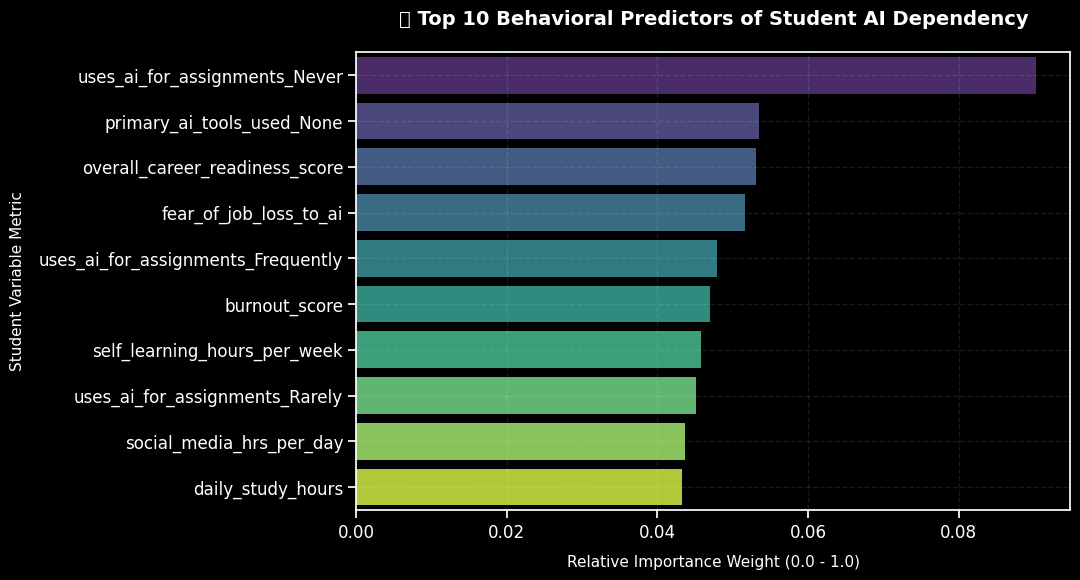

In [ ]:
# --- TRAIN THE RANDOM FOREST MODEL ---
# n_estimators=100 means we are training an ensemble of 100 decision trees
# random_state=42 ensures our results are perfectly reproducible
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("⏳ Training the Random Forest Classifier on student behavioral patterns...")
model.fit(X_train_scaled, y_train)
print("✅ Model training complete.")

# --- EVALUATE ON UNSEEN TEST DATA ---
# Let the model take its "exam" by predicting values for X_test_scaled
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Overall Model Prediction Accuracy: {accuracy * 100:.2f}%")

print("\n📋 Detailed Clinical Classification Report:")
print(classification_report(y_test, y_pred))


# --- EXTRACT AND PLOT FEATURE IMPORTANCES ---
# Map the importance weights back to our original encoded column names
importances = model.feature_importances_
feature_names = X.columns

# Organize into a clean Pandas DataFrame for sorting
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select the top 10 most influential features to keep our dark-themed plot clean
top_10_features = df_importance.head(10)

# Generate the visualization plot
plt.figure(figsize=(11, 6))
plt.style.use('dark_background') # Maintaining your dark theme preference 🌑

sns.barplot(data=top_10_features,x='Importance',y='Feature',palette='viridis',hue='Feature',legend=False)

plt.title('🧠 Top 10 Behavioral Predictors of Student AI Dependency', fontsize=14, pad=20, weight='bold')
plt.xlabel('Relative Importance Weight (0.0 - 1.0)', fontsize=11, labelpad=10)
plt.ylabel('Student Variable Metric', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.1)
plt.tight_layout()

# Save final asset image for your web portfolio implementation
plt.savefig('ai_dependency_feature_importance.png', dpi=300)
plt.show()

## 🎯 Model Evaluation Metrics
The production pipeline yields highly balanced performance profiles across an unseen testing set of 3,000 students:

* **Overall Classification Accuracy:** `78.57%`
* **Precision Metric (Class 1 - High Risk):** `0.79` — Demonstrates that when the model predicts a student is highly dependent on AI, it is correct 79% of the time.
* **Recall / Sensitivity (Class 1 - High Risk):** `0.74` — Confirms the model successfully catches 74% of all actual high-risk profiles within the dataset.
* **F1-Score Balance:** Baseline F1-scores (`0.80` for balanced students, `0.77` for dependent students) reveal a highly stable classification engine that handles target classes without severe algorithmic bias.